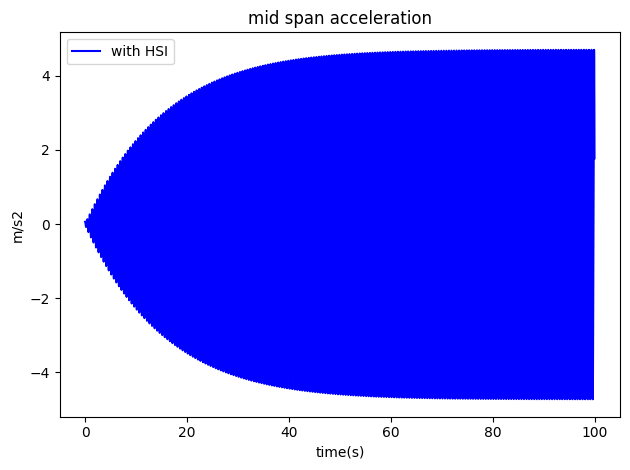

In [4]:
from matrix import*  
from solver import *
from pedestrian import* 
from matplotlib import pyplot as plt
import math
import numpy as np


#step 1 setup beam and pedestrians
#beam
numElements = 10  # n - Number of beam elements !not for modal
length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq = np.array([2,8])  #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2



numbers = 2 #modes bein considered
#modal_mass = 58000 #kg
#def curve1(x):
#    return -3.3245e-23 * x**0 + -1.4885e-02 * x**1 + 7.2714e-04 * x**2 + 1.2637e-04 * x**3 + -1.4437e-05 * x**4 + 7.2750e-07 * x**5 + -1.9644e-08 * x**6 + 3.0059e-10 * x**7 + -2.6205e-12 * x**8 + 1.2166e-14 * x**9 + -2.3396e-17 * x**10 + 9.6919e-29 * x**11

ModalMass = linearMass*length/2


def curve1(x):
    return np.sin(np.pi*x/length)

def curve2(x):
    return np.sin(2*np.pi*x/length)

hht = 0.01
t_end = 100 
func_list=[curve1,curve2] 
modalmass = [ModalMass,ModalMass]
modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12


Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = numbers,
    freq = beamFreq,
      )                   #modes


         
density =0.2

t, u, du, ddu = Newmarksuper_Code(
    Bridge,
    numbers,
    length,
    hht,
    t_end,
    width,
    beamFreq,        # walking frequency fs
    density,            # density ped/m²
    modalDampingRatio,
    density*length*width,
    length * width, # deck area S
    modalmass,
    func_list
)
accn_hsi = accdyn_super_social(Bridge,ddu ,x_interested,modalmass,func_list)
#vertical_displacement = accdyn_super(Bridge,u,25,hht)


plt.plot(t,accn_hsi,label ="with HSI",color='b')
plt.title("mid span acceleration")
plt.xlabel("time(s)")
plt.ylabel("m/s2")
plt.legend()
plt.tight_layout()
#plt.savefig("All In one", format='pdf', dpi=300)  
plt.show()
#print("ddu",ddu)
#print("accn",accn)'''